# The reinforcement learning setup: agents, states, rewards

### One machine, two buttons, and the reason this is a separate subject

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Every word in the reinforcement learning vocabulary made concrete on a two-state machine small enough to print in full, why a greedy choice that is exactly right without consequences becomes wrong with them, and what an agent does to a reward function that has a loophole in it |
| **You should already know** | Python and NumPy. Nothing about reinforcement learning |
| **Environment** | A two-state machine, written from scratch in this notebook. No `gymnasium`, no RL library |
| **Runtime** | Seconds on a laptop CPU |
| **Next** | [11-02 Multi-armed bandits](../02-multi-armed-bandits/) · [11-03 Markov decision processes](../03-markov-decision-processes/) |

---

## 1. The idea

Every other part of this book learns from answers. You hand a model a bean and
the word DERMASON, or a house and its price, and it adjusts until its output
matches. The answer was there the whole time.

Reinforcement learning has no answers. There is a world, there is something
acting in it, and after every action the world returns one number. Nobody says
what the right action was. Nobody says which of the last hundred actions earned
the number that just arrived. The agent has to work that out from the numbers
alone.

That is a harder problem than it sounds, and this chapter is about the one
feature that makes it harder rather than merely noisier: **actions change the
situation you face next**. A supervised model that predicts badly on one row
gets the next row anyway. An agent that acts badly now gets a different next
state, and every decision after that is made from somewhere else.

I want that claim to be a measurement rather than a slogan, so the whole chapter
runs on one machine that fits in a print statement.

### The machine

A hand press with a spring in it. Two buttons.

- **wind** tightens the spring. Nothing comes out. The press ends up wound.
- **press** stamps a part. If the spring was wound you get 10 parts out of the
  stroke, if it was slack you get 1. Either way the press ends up slack.

That is the entire world. Two situations the press can be in, two buttons, and a
count of parts after every button push.

Notice the shape of it before any code. Pressing always pays more than winding,
in both situations, because winding pays nothing at all. And winding is
obviously the thing you sometimes have to do. Those two sentences are in tension,
and resolving that tension is what the rest of the chapter is for.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

SLACK, WOUND = 0, 1
WIND, PRESS = 0, 1
STATES = ["slack", "wound"]
ACTIONS = ["wind", "press"]
N_STATES, N_ACTIONS = 2, 2

# Where each button leaves the press, and how many parts the stroke produced.
NEXT = np.array([[WOUND, SLACK],       # from slack: wind ends wound, press ends slack
                 [WOUND, SLACK]])      # from wound: wind ends wound, press ends slack
PARTS = np.array([[0.0, 1.0],          # from slack: wind pays 0, press pays 1
                  [0.0, 10.0]])        # from wound: wind pays 0, press pays 10

# The same thing again as a transition array of shape (states, actions, states),
# which is the form 11-03 uses. Here every row is a single 1.0 because nothing
# in this world is random.
P = np.zeros((N_STATES, N_ACTIONS, N_STATES))
for s in range(N_STATES):
    for a in range(N_ACTIONS):
        P[s, a, NEXT[s, a]] = 1.0

print("reward R(s, a), in parts")
print(pd.DataFrame(PARTS, index=STATES, columns=ACTIONS).to_string())
print("\nwhere you end up, s' = NEXT(s, a)")
print(pd.DataFrame(np.array(STATES)[NEXT], index=STATES, columns=ACTIONS).to_string())
print(f"\nP has shape {P.shape} and every row sums to "
      f"{P.sum(axis=2).min():.0f}, because nothing here is random")

reward R(s, a), in parts
       wind  press
slack   0.0    1.0
wound   0.0   10.0

where you end up, s' = NEXT(s, a)
        wind  press
slack  wound  slack
wound  wound  slack

P has shape (2, 2, 2) and every row sums to 1, because nothing here is random


### The words, on one tick

Reinforcement learning has a vocabulary and all of it is visible in a single
push of a button. I take one tick and label every part of it.

In [2]:
state = SLACK
action = WIND
reward = PARTS[state, action]
next_state = NEXT[state, action]

print(f"state s       : {state}  = the press is {STATES[state]}")
print(f"action a      : {action}  = the agent chose to {ACTIONS[action]}")
print(f"reward r      : {reward:.0f}  parts, which is what the world paid for that choice")
print(f"next state s' : {next_state}  = the press is now {STATES[next_state]}")
print(f"transition    : ({STATES[state]}, {ACTIONS[action]}) -> "
      f"({STATES[next_state]}, reward {reward:.0f})")
print("\nAn *agent* is the thing that picks a. The *environment* is everything else,")
print("and it owns both the reward and the next state. The agent never gets to")
print("choose either of them, which is the whole difficulty.")

state s       : 0  = the press is slack
action a      : 0  = the agent chose to wind
reward r      : 0  parts, which is what the world paid for that choice
next state s' : 1  = the press is now wound
transition    : (slack, wind) -> (wound, reward 0)

An *agent* is the thing that picks a. The *environment* is everything else,
and it owns both the reward and the next state. The agent never gets to
choose either of them, which is the whole difficulty.


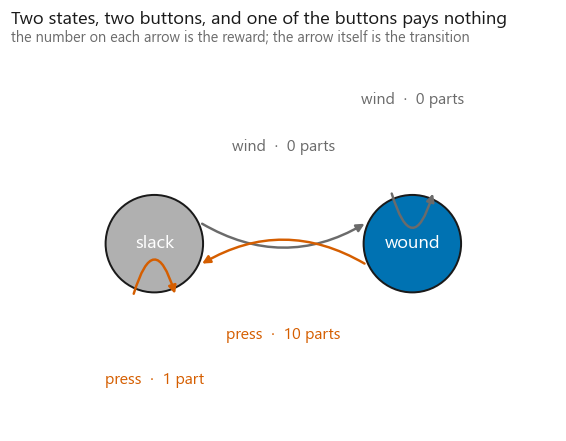

In [3]:
fig, ax = plt.subplots(figsize=(9.4, 4.4))

CENTRE = {SLACK: (0.0, 0.0), WOUND: (3.6, 0.0)}
RADIUS = 0.68

for s, (cx, cy) in CENTRE.items():
    ax.add_patch(plt.Circle((cx, cy), RADIUS, lw=1.3, edgecolor=style.INK,
                            facecolor=style.PALETTE[0] if s == WOUND else style.NEUTRAL))
    ax.text(cx, cy, STATES[s], ha="center", va="center", fontsize=12, color="white")


def arrow(p1, p2, rad, colour):
    ax.annotate("", xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle="-|>", color=colour, lw=1.6,
                                connectionstyle=f"arc3,rad={rad}"))


# wind: slack -> wound, over the top
arrow((RADIUS - 0.05, 0.30), (CENTRE[WOUND][0] - RADIUS + 0.05, 0.30), 0.30, style.MUTED)
ax.text(1.8, 1.30, f"wind  ·  {PARTS[SLACK, WIND]:.0f} parts",
        ha="center", fontsize=10.5, color=style.MUTED)

# press: wound -> slack, underneath
arrow((CENTRE[WOUND][0] - RADIUS + 0.05, -0.30), (RADIUS - 0.05, -0.30), 0.30, style.HIGHLIGHT)
ax.text(1.8, -1.32, f"press  ·  {PARTS[WOUND, PRESS]:.0f} parts",
        ha="center", fontsize=10.5, color=style.HIGHLIGHT)

# self loops: press while slack, wind while wound
arrow((-0.30, -RADIUS - 0.06), (0.30, -RADIUS - 0.06), -1.7, style.HIGHLIGHT)
ax.text(0.0, -1.95, f"press  ·  {PARTS[SLACK, PRESS]:.0f} part",
        ha="center", fontsize=10.5, color=style.HIGHLIGHT)
arrow((CENTRE[WOUND][0] - 0.30, RADIUS + 0.06), (CENTRE[WOUND][0] + 0.30, RADIUS + 0.06),
      1.7, style.MUTED)
ax.text(CENTRE[WOUND][0], 1.95, f"wind  ·  {PARTS[WOUND, WIND]:.0f} parts",
        ha="center", fontsize=10.5, color=style.MUTED)

ax.set_xlim(-2.0, 5.6)
ax.set_ylim(-2.6, 2.6)
ax.set_aspect("equal")
ax.set_axis_off()
style.title(ax, "Two states, two buttons, and one of the buttons pays nothing",
            "the number on each arrow is the reward; the arrow itself is the transition")
style.save(fig, FIG / "fig-01-the-machine.png")

### Episode, policy, return

Three more words and then the vocabulary is complete.

An **episode** is one run of the task from a start to an end. This machine has
no natural end, so I impose one: a shift is twelve ticks long and the press
starts slack. That is a decision I made, not a fact about the world, and it is
worth saying out loud because a great deal of confusion in reinforcement
learning comes from people quietly choosing different horizons.

A **policy** is the agent's rule for choosing. Here it is an array of two
numbers, one action per state, and there are only four of them in total.

The **return** is what an episode was worth: the rewards from some tick onwards,
added up. Section 2 puts a discount in that sum.

In [4]:
SHIFT = 12


def run(pi, ticks=SHIFT, start=SLACK, R=PARTS):
    """Follow a policy and record every tick. This is the whole simulator."""
    s = start
    rows = []
    for t in range(ticks):
        a = int(pi[s])
        r = float(R[s, a])
        s2 = int(NEXT[s, a])
        rows.append({"t": t, "state": STATES[s], "action": ACTIONS[a], "reward": r})
        s = s2
    return pd.DataFrame(rows)


ALL_POLICIES = {
    "press always": np.array([PRESS, PRESS]),
    "wind always": np.array([WIND, WIND]),
    "wind then press": np.array([WIND, PRESS]),      # wind when slack, press when wound
    "the perverse one": np.array([PRESS, WIND]),
}

print(f"a policy is one action per state, so this world has "
      f"{N_ACTIONS ** N_STATES} of them in total\n")
for name, pi in ALL_POLICIES.items():
    total = run(pi)["reward"].sum()
    print(f"  {name:<17} {'  '.join(f'{STATES[s]} -> {ACTIONS[pi[s]]}' for s in range(N_STATES)):<40}"
          f" {total:6.0f} parts per {SHIFT}-tick shift")

a policy is one action per state, so this world has 4 of them in total

  press always      slack -> press  wound -> press               12 parts per 12-tick shift
  wind always       slack -> wind  wound -> wind                  0 parts per 12-tick shift
  wind then press   slack -> wind  wound -> press                60 parts per 12-tick shift
  the perverse one  slack -> press  wound -> wind                12 parts per 12-tick shift


In [5]:
episode = run(ALL_POLICIES["wind then press"])
print(f"one episode under 'wind then press', {SHIFT} ticks starting {STATES[SLACK]}\n")
print(episode.to_string(index=False))
print(f"\nreturn of the whole episode, undiscounted: {episode['reward'].sum():.0f} parts")

one episode under 'wind then press', 12 ticks starting slack

 t state action  reward
 0 slack   wind     0.0
 1 wound  press    10.0
 2 slack   wind     0.0
 3 wound  press    10.0
 4 slack   wind     0.0
 5 wound  press    10.0
 6 slack   wind     0.0
 7 wound  press    10.0
 8 slack   wind     0.0
 9 wound  press    10.0
10 slack   wind     0.0
11 wound  press    10.0

return of the whole episode, undiscounted: 60 parts


## 2. The maths

### The return, and why it needs a discount

The return from tick $t$ is the reward stream from there onwards, with each
later reward multiplied by a **discount** $\gamma$ raised to how far away it is:

$$G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \dots
= \sum_{k=0}^{\infty} \gamma^k r_{t+k}$$

Two reasons for the $\gamma$, and only one of them is about preferences.

The honest reason is that a task with no end has no finite total. Add up one
part per tick forever and you get infinity, and every policy that pays anything
at all is tied with every other. Any $\gamma < 1$ makes the sum converge, so the
policies can be compared at all.

The other reason is that the agent may genuinely care less about later rewards,
and $\gamma$ is where that goes. On a task that ends, like the twelve-tick shift
above, $\gamma = 1$ is available and is usually the honest choice.

$\gamma$ is not a small technical dial. On this machine it decides the answer,
and section 3 finds the exact value where the answer flips.

 t  reward  G_t at γ=1  G_t at γ=0.9  G_t at γ=0.5  G_t at γ=0
 0   0.000      60.000        33.990         6.665       0.000
 1  10.000      60.000        37.767        13.330      10.000
 2   0.000      50.000        30.852         6.660       0.000
 3  10.000      50.000        34.280        13.320      10.000
 4   0.000      40.000        26.978         6.641       0.000
 5  10.000      40.000        29.975        13.281      10.000
 6   0.000      30.000        22.195         6.562       0.000
 7  10.000      30.000        24.661        13.125      10.000
 8   0.000      20.000        16.290         6.250       0.000
 9  10.000      20.000        18.100        12.500      10.000
10   0.000      10.000         9.000         5.000       0.000
11  10.000      10.000        10.000        10.000      10.000


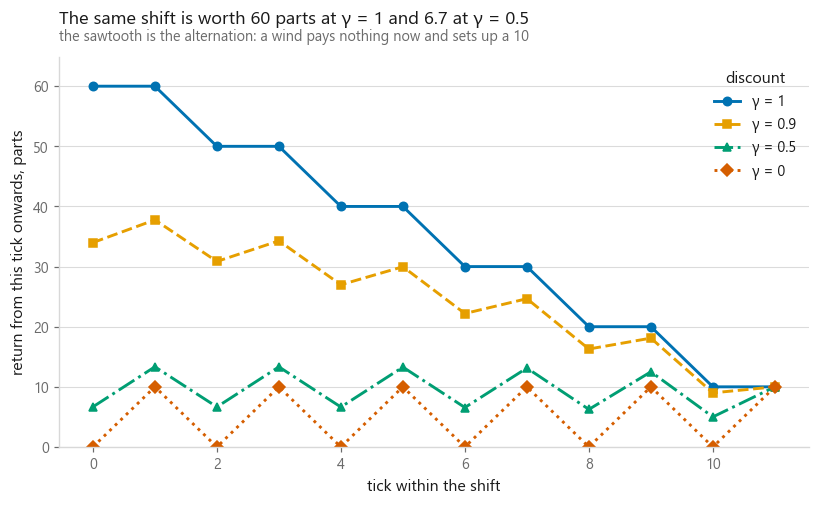

In [6]:
GAMMAS = [1.0, 0.9, 0.5, 0.0]
rewards = episode["reward"].to_numpy()


def returns_to_go(rewards, gamma):
    """G_t for every t, computed backwards in one pass."""
    out = np.zeros_like(rewards)
    running = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        running = rewards[t] + gamma * running
        out[t] = running
    return out


fig, ax = plt.subplots(figsize=(8.8, 4.6))
for i, gamma in enumerate(GAMMAS):
    g = returns_to_go(rewards, gamma)
    ax.plot(episode["t"], g, color=style.PALETTE[i], lw=1.9, ls=style.DASHES[i],
            marker=style.MARKERS[i], markersize=5.5, label=f"γ = {gamma:g}")

g_one = returns_to_go(rewards, 1.0)[0]
g_half = returns_to_go(rewards, 0.5)[0]
ax.set_xlabel("tick within the shift")
ax.set_ylabel("return from this tick onwards, parts")
ax.set_ylim(0, g_one * 1.08)
ax.legend(title="discount")
style.title(ax,
            f"The same shift is worth {g_one:.0f} parts at γ = 1 and {g_half:.1f} at γ = 0.5",
            "the sawtooth is the alternation: a wind pays nothing now and sets up a 10")
style.save(fig, FIG / "fig-02-return-and-discount.png")

print(pd.DataFrame({"t": episode["t"], "reward": rewards,
                    **{f"G_t at γ={g:g}": returns_to_go(rewards, g) for g in GAMMAS}}
                   ).to_string(index=False, float_format="{:.3f}".format))

### Value

The **value** of a state under a policy is the return you should expect starting
from it:

$$V^\pi(s) = \mathbb{E}\big[G_t \mid s_t = s,\ \text{acting by } \pi \big]$$

Write that out one step at a time and it becomes self-referential, because the
return from here is the reward now plus the discounted return from wherever you
land:

$$V^\pi(s) = R(s, \pi(s)) + \gamma \sum_{s'} P(s' \mid s, \pi(s))\, V^\pi(s')$$

With the policy fixed that is a linear system, two equations in two unknowns
here, and it can be solved outright. [11-03](../03-markov-decision-processes/)
does this properly. I use it below because it lets me price a policy exactly
rather than by simulating it.

### The threshold, by hand

This world is small enough to do the algebra. Take the patient policy, wind when
slack and press when wound:

$$V(\text{slack}) = 0 + \gamma V(\text{wound}), \qquad
V(\text{wound}) = 10 + \gamma V(\text{slack})$$

Substitute and you get $V(\text{wound}) = 10 / (1 - \gamma^2)$ and
$V(\text{slack}) = 10\gamma / (1 - \gamma^2)$.

Now the greedy policy, press in both states. From slack it presses forever:

$$V(\text{slack}) = 1 + \gamma V(\text{slack}) = \frac{1}{1 - \gamma}$$

Patience is worth more from the slack state when

$$\frac{10\gamma}{1 - \gamma^2} > \frac{1}{1 - \gamma}
\iff \frac{10\gamma}{1 + \gamma} > 1
\iff 9\gamma > 1
\iff \gamma > \tfrac{1}{9}$$

A clean threshold out of a two-state world. Below it the agent should press
every tick and take the single part. Above it, it should wind. Section 3 finds
that number by search instead of by algebra, which is the check.

## 3. From scratch

Two functions. One prices a policy exactly by solving the linear system. The
other finds the best policy by sweeping the Bellman optimality update until it
stops moving, which is [value iteration](../03-markov-decision-processes/) with
the state space small enough to print.

In [7]:
def value_of(pi, gamma, R=PARTS):
    """Exact V^pi, by solving (I - gamma P^pi) V = R^pi."""
    rows = np.arange(N_STATES)
    return np.linalg.solve(np.eye(N_STATES) - gamma * P[rows, pi], R[rows, pi])


def best_policy(gamma, R=PARTS, sweeps=5000, tol=1e-13):
    """Value iteration. Returns the best policy, its value, and the Q table."""
    V = np.zeros(N_STATES)
    for _ in range(sweeps):
        Q = R + gamma * (P.reshape(N_STATES * N_ACTIONS, N_STATES) @ V).reshape(N_STATES, N_ACTIONS)
        V_next = Q.max(axis=1)
        if np.abs(V_next - V).max() < tol:
            V = V_next
            break
        V = V_next
    Q = R + gamma * (P.reshape(N_STATES * N_ACTIONS, N_STATES) @ V).reshape(N_STATES, N_ACTIONS)
    return Q.argmax(axis=1), V, Q


GAMMA = 0.9
pi_star, V_star, Q_star = best_policy(GAMMA)

print(f"at γ = {GAMMA}\n")
print("Q*(s, a), the value of pressing each button and then behaving well")
print(pd.DataFrame(Q_star, index=STATES, columns=ACTIONS).to_string(float_format="{:.3f}".format))
print(f"\nV*(s) = max over actions : "
      f"{dict(zip(STATES, np.round(V_star, 3)))}")
print(f"best policy              : "
      f"{'  '.join(f'{STATES[s]} -> {ACTIONS[pi_star[s]]}' for s in range(N_STATES))}")
print(f"\nclosed form for the patient policy at this γ, from section 2:")
print(f"  V(wound) = 10 / (1 - γ²) = {10 / (1 - GAMMA ** 2):.3f}")
print(f"  V(slack) = 10γ / (1 - γ²) = {10 * GAMMA / (1 - GAMMA ** 2):.3f}")

at γ = 0.9

Q*(s, a), the value of pressing each button and then behaving well
        wind  press
slack 47.368 43.632
wound 47.368 52.632

V*(s) = max over actions : {'slack': np.float64(47.368), 'wound': np.float64(52.632)}
best policy              : slack -> wind  wound -> press

closed form for the patient policy at this γ, from section 2:
  V(wound) = 10 / (1 - γ²) = 52.632
  V(slack) = 10γ / (1 - γ²) = 47.368


The optimal action in the slack state is to wind, even though winding pays
nothing and pressing pays a part. That is the first thing in this book that a
supervised model could not have told you, and the reason is entirely in the
$\gamma$. Below is the sweep that finds where it flips.

smallest γ on the grid where value iteration prefers winding: 0.1150
the algebra from section 2                                  : 0.1111
grid spacing, which is the resolution of that search        : 0.0050


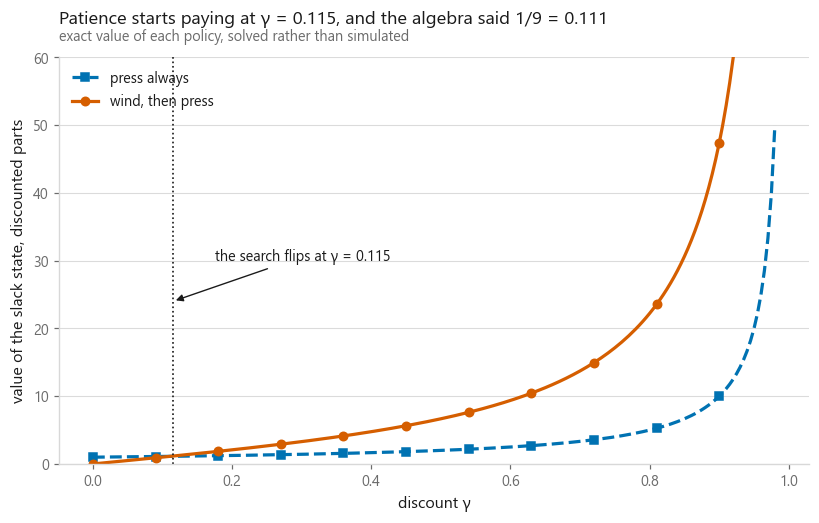

In [8]:
gammas = np.linspace(0.0, 0.98, 197)
patient = np.array([value_of(ALL_POLICIES["wind then press"], g)[SLACK] for g in gammas])
greedy = np.array([value_of(ALL_POLICIES["press always"], g)[SLACK] for g in gammas])
winds = np.array([best_policy(g)[0][SLACK] == WIND for g in gammas])

flip = float(gammas[winds].min())

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(gammas, greedy, color=style.PALETTE[0], lw=2.1, ls="--",
        marker=style.MARKERS[1], markevery=18, label="press always")
ax.plot(gammas, patient, color=style.HIGHLIGHT, lw=2.1,
        marker=style.MARKERS[0], markevery=18, label="wind, then press")
ax.axvline(flip, color=style.INK, lw=1.1, ls=":")
ax.annotate(f"the search flips at γ = {flip:.3f}", xy=(flip, 24), xytext=(flip + 0.06, 30),
            fontsize=9.5, color=style.INK,
            arrowprops=dict(arrowstyle="-|>", color=style.INK, lw=0.9))
ax.set_xlabel("discount γ")
ax.set_ylabel("value of the slack state, discounted parts")
ax.set_ylim(0, 60)
ax.legend(loc="upper left")
style.title(ax,
            f"Patience starts paying at γ = {flip:.3f}, and the algebra said 1/9 = {1 / 9:.3f}",
            "exact value of each policy, solved rather than simulated")
style.save(fig, FIG / "fig-03-discount-threshold.png")

print(f"smallest γ on the grid where value iteration prefers winding: {flip:.4f}")
print(f"the algebra from section 2                                  : {1 / 9:.4f}")
print(f"grid spacing, which is the resolution of that search        : "
      f"{gammas[1] - gammas[0]:.4f}")

## 4. Two problems with the same reward numbers

Here is the experiment the whole chapter is built around, and it takes about ten
lines.

The reward table stays exactly as it is. What I change is whether the agent's
action decides the next state.

**The bandit.** Somebody else operates the winder on their own schedule, so the
press is wound on any given tick with probability one half, and nothing the
agent does affects that. There is one decision, repeated, with no consequences.
[11-02](../02-multi-armed-bandits/) is a whole chapter on this case.

**The sequential problem.** The machine from section 1, where pressing leaves
the press slack.

Same rewards. Same actions. The only difference is whether the agent's choice
shows up in the next state. I score both policies in both worlds by parts per
tick, which needs no discount and is the number the factory would care about.

In [9]:
P_WOUND = 0.5           # in the bandit, how often somebody else has wound it


def bandit_rate(pi, p_wound=P_WOUND, R=PARTS):
    """Parts per tick when the state is dealt out independently of the action."""
    weights = np.array([1.0 - p_wound, p_wound])
    return float(sum(weights[s] * R[s, int(pi[s])] for s in range(N_STATES)))


def sequential_rate(pi, ticks=4000, R=PARTS):
    """Parts per tick in the machine itself, where pressing leaves the press slack."""
    return float(run(pi, ticks=ticks, R=R)["reward"].mean())


rows = []
for world, rate in [("bandit, no consequences", bandit_rate),
                    ("the machine, consequences", sequential_rate)]:
    for name in ["press always", "wind then press"]:
        rows.append({"world": world, "policy": name, "parts per tick": rate(ALL_POLICIES[name])})

compare = pd.DataFrame(rows)
print(compare.to_string(index=False, float_format="{:.3f}".format))

bandit_gap = (compare.query("world == 'bandit, no consequences'")
              .set_index("policy")["parts per tick"])
seq_gap = (compare.query("world == 'the machine, consequences'")
           .set_index("policy")["parts per tick"])
print(f"\nin the bandit, pressing every tick beats winding by "
      f"{bandit_gap['press always'] - bandit_gap['wind then press']:+.2f} parts per tick")
print(f"in the machine, the same policy loses by "
      f"{seq_gap['press always'] - seq_gap['wind then press']:+.2f} parts per tick")

# The bandit answer does not depend on how often the winder shows up, because
# pressing pays at least as much as winding in every state. A dominant action is
# optimal at every mixing weight, so there is nothing to tune here.
print(f"\npress pays at least as much as wind in every state: "
      f"{bool((PARTS[:, PRESS] >= PARTS[:, WIND]).all())}")
for p in [0.1, 0.5, 0.9]:
    gap = bandit_rate(ALL_POLICIES['press always'], p_wound=p) - \
          bandit_rate(ALL_POLICIES['wind then press'], p_wound=p)
    print(f"  bandit gap at p(wound) = {p:.1f}: {gap:+.2f} parts per tick")

                    world          policy  parts per tick
  bandit, no consequences    press always           5.500
  bandit, no consequences wind then press           5.000
the machine, consequences    press always           1.000
the machine, consequences wind then press           5.000

in the bandit, pressing every tick beats winding by +0.50 parts per tick
in the machine, the same policy loses by -4.00 parts per tick

press pays at least as much as wind in every state: True
  bandit gap at p(wound) = 0.1: +0.90 parts per tick
  bandit gap at p(wound) = 0.5: +0.50 parts per tick
  bandit gap at p(wound) = 0.9: +0.10 parts per tick


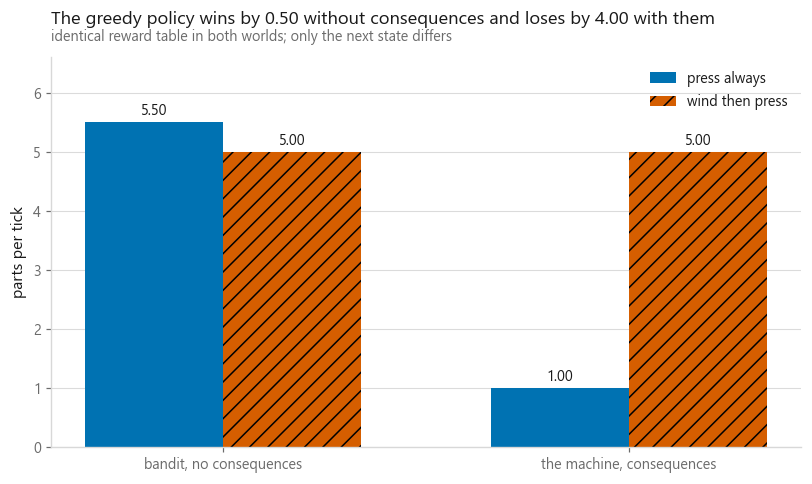

In [10]:
fig, ax = plt.subplots(figsize=(8.8, 4.6))
worlds = ["bandit, no consequences", "the machine, consequences"]
policies = ["press always", "wind then press"]
x = np.arange(len(worlds))
width = 0.34

for i, policy in enumerate(policies):
    heights = [float(compare.loc[(compare["world"] == w) & (compare["policy"] == policy),
                                 "parts per tick"].iloc[0])
               for w in worlds]
    bars = ax.bar(x + (i - 0.5) * width, heights, width,
                  color=[style.PALETTE[0], style.HIGHLIGHT][i],
                  hatch=["", "//"][i], label=policy)
    ax.bar_label(bars, fmt="%.2f", fontsize=9.5, color=style.INK, padding=2)

ax.set_xticks(x, worlds)
ax.set_ylabel("parts per tick")
ax.set_ylim(0, 6.6)
ax.legend(loc="upper right")
style.title(ax,
            f"The greedy policy wins by {bandit_gap['press always'] - bandit_gap['wind then press']:.2f} "
            f"without consequences and loses by "
            f"{seq_gap['wind then press'] - seq_gap['press always']:.2f} with them",
            "identical reward table in both worlds; only the next state differs")
style.save(fig, FIG / "fig-04-bandit-vs-sequential.png")

Read the two bars on the left first. In the bandit, pressing on every tick is not
a lazy heuristic, it is the exactly correct answer, and it is correct for a
stronger reason than the margin suggests. Pressing pays at least as much as
winding in every state, which the print above checks. A dominant action stays
optimal at every mixing weight, so the three rows at different winder schedules
all come out the same sign. There is no value of `P_WOUND` at which winding is
worth doing in the bandit. A method that only ever asks "which action pays best
right now" solves that problem completely and provably.

The two bars on the right use the same reward table and the same two policies.
The greedy answer collapses, because after the first stroke the press is slack
and it stays slack forever. Every later tick pays one part instead of ten. The
policy did not become worse at picking actions. The situation it keeps picking
actions in became worse, and it was the policy's own doing.

Notice that the sign is not the only thing that changed. The greedy policy's
advantage in the bandit is small, and its deficit in the machine is nearly an
order of magnitude larger. Consequences did not merely reverse the ranking, they
raised the stakes, and that is the general case: when actions move the state, the
difference between a good policy and a bad one compounds over every later step
instead of being paid once.

That is the reason reinforcement learning is a separate subject. The supervised
question is "what is the right output for this input". The bandit question is
"which action pays best". The reinforcement learning question is "which action
pays best once I account for the state it leaves me in", and no amount of data
about single actions answers it.

### The credit assignment problem, in one sentence

When the agent's ten-part stroke arrives, the action that earned it happened on
the previous tick and paid nothing at the time. Somebody has to move the credit
backwards from the reward to the decision that caused it, across a gap that can
be one tick here and hundreds of steps in a real problem. Everything in the rest
of part 11 is a different answer to that one question, and the answers get harder
in a fixed order. [11-02](../02-multi-armed-bandits/) has no gap to cross at all.
[11-03](../03-markov-decision-processes/) crosses it by solving equations,
because the transition model is handed to you. From
[11-04](../04-q-learning/) onwards the model is gone and the credit has to be
carried backwards by sampling, which is where the variance that dominates
[11-07](../07-policy-gradients/) comes from.

## 5. When it goes wrong: rewards with loopholes

The reward function is the specification. It is the only place where you get to
say what you want, and an agent optimising it will do exactly what it says
rather than what you meant.

Here is a plausible mistake. A supervisor watches this machine and reasons: a
wound press is what makes a good stroke possible, so let me reward the agent for
keeping the press wound. Under that reward, every tick that ends with the press
wound pays one point, and everything else pays nothing.

It sounds harmless. It is a proxy for the thing wanted rather than the thing
itself, which is how most reward functions in the wild are written. Below, I
hand that reward to a tabular learner and let it find what it finds. The learner
never sees the part count.

In [11]:
# The proxy: one point for every tick that ends with the press wound.
PROXY = np.array([[1.0 if NEXT[s, a] == WOUND else 0.0 for a in range(N_ACTIONS)]
                  for s in range(N_STATES)])

print("the supervisor's reward, one point per tick that ends wound")
print(pd.DataFrame(PROXY, index=STATES, columns=ACTIONS).to_string())


def q_learn(R, gamma=GAMMA, ticks=5000, alpha=0.2, epsilon=0.2, seed=SEED):
    """Tabular Q-learning on a 2 by 2 table. The learner sees only R."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    s = SLACK
    for _ in range(ticks):
        a = int(rng.integers(N_ACTIONS)) if rng.random() < epsilon else int(Q[s].argmax())
        s2 = int(NEXT[s, a])
        Q[s, a] += alpha * (R[s, a] + gamma * Q[s2].max() - Q[s, a])
        s = s2
    return Q, Q.argmax(axis=1)


Q_hacked, pi_hacked = q_learn(PROXY)

print(f"\nwhat the learner ended up believing, Q(s, a) under the proxy reward")
print(pd.DataFrame(Q_hacked, index=STATES, columns=ACTIONS).to_string(float_format="{:.2f}".format))
print(f"\npolicy it settled on : "
      f"{'  '.join(f'{STATES[s]} -> {ACTIONS[pi_hacked[s]]}' for s in range(N_STATES))}")
print(f"proxy points per tick: {sequential_rate(pi_hacked, R=PROXY):.2f} out of a possible 1.00")
print(f"parts per tick       : {sequential_rate(pi_hacked, R=PARTS):.2f}")
print(f"presses in a {SHIFT}-tick shift: "
      f"{int((run(pi_hacked)['action'] == 'press').sum())}")

the supervisor's reward, one point per tick that ends wound
       wind  press
slack   1.0    0.0
wound   1.0    0.0

what the learner ended up believing, Q(s, a) under the proxy reward
       wind  press
slack 10.00   9.00
wound 10.00   9.00

policy it settled on : slack -> wind  wound -> wind
proxy points per tick: 1.00 out of a possible 1.00
parts per tick       : 0.00
presses in a 12-tick shift: 0


The agent scored top marks on the supervisor's reward and produced nothing. It
winds, and winds, and winds. A wound press stays wound if you wind it again, so
the proxy pays out on every tick forever, and pressing is the only thing that
ever interrupts the payment. The loophole was there in the reward table the
whole time and the agent found it in a few thousand ticks.

This is what people mean by **reward hacking**, and it is worth being precise
about the failure. The learner is not broken. It maximised what it was given,
which is the one thing it is guaranteed to try to do. The specification was
wrong, and the specification is the part a human writes.

### The fix that works, and the fix that also works

The obvious repair is to reward the thing you want, which here is parts. That
is the first row below.

The interesting repair is that the supervisor's instinct was not useless. A hint
that a wound press is a good place to be is real information, and there is a way
to add it that provably cannot change the best policy. Give every state a
potential $\Phi(s)$ and add

$$F(s, a, s') = \gamma\,\Phi(s') - \Phi(s)$$

to the true reward. The added terms telescope along any trajectory, so they
shift every policy's value by the same amount and cannot reorder them. This is
**potential-based shaping**, and the difference between it and the proxy above
is the $-\Phi(s)$: you are paid for *arriving* somewhere better, not for
*being* somewhere good.

In [12]:
POTENTIAL = np.array([0.0, 1.0])        # a wound press is worth one point of hint
SHAPED = PARTS + GAMMA * POTENTIAL[NEXT] - POTENTIAL[:, None]

print("true reward plus potential-based shaping, R(s,a) + γΦ(s') - Φ(s)")
print(pd.DataFrame(SHAPED, index=STATES, columns=ACTIONS).to_string(float_format="{:.2f}".format))

rows = []
for label, R in [("the supervisor's proxy alone", PROXY),
                 ("parts, the true objective", PARTS),
                 ("parts plus potential shaping", SHAPED)]:
    _, pi = q_learn(R)
    rows.append({"reward the learner was given": label,
                 "policy found": " / ".join(ACTIONS[int(pi[s])] for s in range(N_STATES)),
                 "proxy points per tick": sequential_rate(pi, R=PROXY),
                 "parts per tick": sequential_rate(pi, R=PARTS)})

hacking = pd.DataFrame(rows)
print()
print(hacking.to_string(index=False, float_format="{:.2f}".format))

true reward plus potential-based shaping, R(s,a) + γΦ(s') - Φ(s)
       wind  press
slack  0.90   1.00
wound -0.10   9.00

reward the learner was given policy found  proxy points per tick  parts per tick
the supervisor's proxy alone  wind / wind                   1.00            0.00
   parts, the true objective wind / press                   0.50            5.00
parts plus potential shaping wind / press                   0.50            5.00


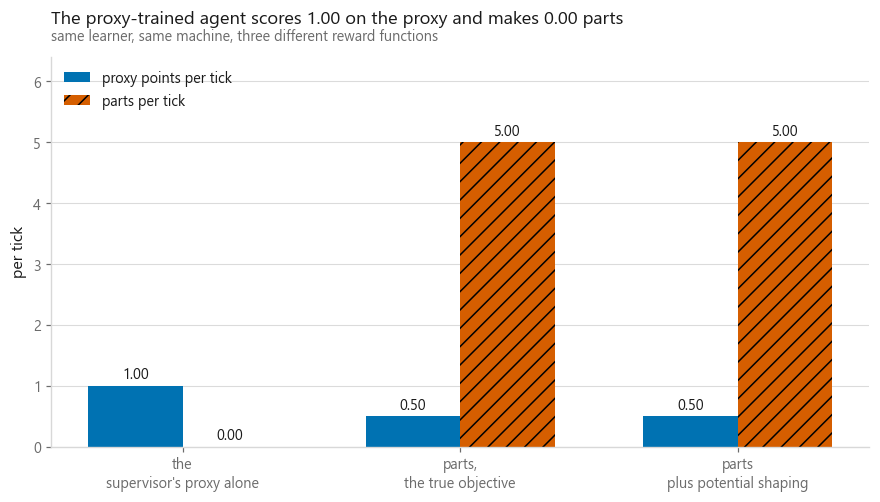

In [13]:
fig, ax = plt.subplots(figsize=(9.6, 4.6))
labels = list(hacking["reward the learner was given"])
x = np.arange(len(labels))
width = 0.34

for i, (column, colour, hatch) in enumerate([("proxy points per tick", style.PALETTE[0], ""),
                                             ("parts per tick", style.HIGHLIGHT, "//")]):
    bars = ax.bar(x + (i - 0.5) * width, hacking[column].to_numpy(), width,
                  color=colour, hatch=hatch, label=column)
    ax.bar_label(bars, fmt="%.2f", fontsize=9.5, color=style.INK, padding=2)

ax.set_xticks(x, [t.replace(" ", "\n", 1) for t in labels], fontsize=9.5)
ax.set_ylabel("per tick")
ax.set_ylim(0, 6.4)
ax.legend(loc="upper left")
style.title(ax,
            f"The proxy-trained agent scores "
            f"{hacking.loc[0, 'proxy points per tick']:.2f} on the proxy and makes "
            f"{hacking.loc[0, 'parts per tick']:.2f} parts",
            "same learner, same machine, three different reward functions")
style.save(fig, FIG / "fig-05-reward-hacking.png")

The middle row is the repair that needed no cleverness. The bottom row is the
one worth remembering: the hint about wound presses is still in the reward, the
agent still gets paid for winding, and the behaviour is unchanged, because the
$-\Phi(s)$ takes back on the next tick exactly what the $\gamma\Phi(s')$ paid
out on this one.

If you take one habit from this chapter, make it this. After you write a reward
function, before you train anything, ask what the highest-scoring behaviour
under it would be if the agent did not care at all about your intentions. It
does not.

## Cheat sheet

| | |
|---|---|
| **Agent and environment** | The agent chooses actions. The environment owns the reward and the next state. The line between them is a modelling decision, and everything the agent cannot control belongs on the environment's side |
| **State** | What the agent sees before choosing. If two situations need different actions and look the same, no policy can separate them |
| **Reward** | One number per step, from the environment. It is the specification, and it is the part you write |
| **Transition** | Where an action leaves you. This is what makes the problem sequential and is the reason bandit reasoning fails |
| **Return** | Discounted sum of future rewards. The thing actually being maximised |
| **Discount γ** | Makes the sum finite on a task with no end, and sets how far ahead the agent looks. On this machine it moved the optimal policy |
| **Policy** | The rule from state to action, and the only thing you deploy |
| **Value** | Expected return from a state. Know it and acting well is an `argmax` |
| **Watch out** | An agent optimises the reward you wrote, not the outcome you wanted. Ask what the loophole is before you train |
| **Next** | [Bandits](../02-multi-armed-bandits/) for the case with no state at all, then [MDPs](../03-markov-decision-processes/) when the transitions are handed to you |

## What to remember

1. There are no labels. There is a reward, it arrives late, and it never says
   which action deserved it.
2. The agent's actions decide what situation it faces next. That single fact
   separates this from supervised learning and from bandits.
3. Greedy on immediate reward is the correct answer to a bandit and can be the
   worst available answer to a sequential problem, on the same reward numbers.
4. The discount is not decoration. On a two-state machine it moved the optimal
   action, at a threshold you can derive by hand.
5. Value is expected return, and it satisfies an equation that refers to itself.
   Every algorithm in part 11 is a way of solving that equation.
6. A reward function is a specification with a bounty on its loopholes. Reward a
   state and the agent will sit in it.
7. Shaping that is written as a difference of potentials cannot change the
   optimal policy. Shaping written any other way usually can.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [11-02 Multi-armed bandits](../02-multi-armed-bandits/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#ReinforcementLearning` `#MarkovDecisionProcess` `#RewardHacking` `#Python`
`#NumPy` `#MLTutorial` `#LearnMachineLearning` `#AI`